<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/train_1s_30hz_2class_real_world_phase_1_to_3_version_a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train real world data phase 1 to 3 test person a

In [1]:
# Author: Ziyi Liu
# Project: Bachelor's Thesis - Cyclist Curb Detection under Varying Road Roughness
# Institution: Universität Kassel
# License: GNU General Public License v3.0

%load_ext autoreload
%autoreload 2

## 1. Data loading

### a)VS Code

In [ ]:

%load_ext autoreload
%autoreload 2

import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import sys
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

sys.path.append('../')   # Add parent directory to Python path
working_directory = "../models/"
sys.path.append('../../')
from utils.preprocessing import *

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

In [ ]:
# load balanced data
with open('../training_data/lab_real_world_2class_balanced_version_a/X_train_normalized.pkl', 'rb') as f:
    np_train_balanced_data = pickle.load(f)
with open('../training_data/lab_real_world_2class_balanced_version_a/X_val_normalized.pkl', 'rb') as f:
    np_val_balanced_data = pickle.load(f)
np_train_balanced_data.shape, np_val_balanced_data.shape


((1638, 30, 3), (410, 30, 3))

In [ ]:
# Combine np_train_balanced_data and np_val_balanced_data
np_combined_balanced_data = np.concatenate((np_train_balanced_data, np_val_balanced_data), axis=0)
np_combined_balanced_data.shape

(2048, 30, 3)

In [ ]:
# Save combined balanced data as pickle file
with open('../training_data/lab_real_world_2class_balanced_version_a/X_train_normalized_2.pkl', 'wb') as f:
    pickle.dump(np_combined_balanced_data, f)

print(f"Saved combined balanced data with shape: {np_combined_balanced_data.shape}")

Saved combined balanced data with shape: (2048, 30, 3)


In [ ]:
# load unbalanced data
with open('../training_data/lab_real_world_2class_unbalanced_version_b/X_train_normalized.pkl', 'rb') as f:
    np_train_unbalanced_data = pickle.load(f)
with open('../training_data/lab_real_world_2class_unbalanced_version_b/y_train_onehot.pkl', 'rb') as f:
    np_train_unbalanced_labels = pickle.load(f)
with open('../training_data/lab_real_world_2class_unbalanced_version_b/X_val_normalized.pkl', 'rb') as f:
    np_val_unbalanced_data = pickle.load(f)
with open('../training_data/lab_real_world_2class_unbalanced_version_b/y_val_onehot.pkl', 'rb') as f:
    np_val_unbalanced_labels = pickle.load(f)
with open('../training_data/lab_real_world_2class_unbalanced_version_b/X_test_normalized.pkl', 'rb') as f:
    np_test_unbalanced_data = pickle.load(f)
with open('../training_data/lab_real_world_2class_unbalanced_version_b/y_test_onehot.pkl', 'rb') as f:
    np_test_unbalanced_labels = pickle.load(f)
np_train_unbalanced_data.shape, np_train_unbalanced_labels.shape, np_val_unbalanced_data.shape, np_val_unbalanced_labels.shape, np_test_unbalanced_data.shape, np_test_unbalanced_labels.shape

((27877, 30, 3),
 (27877, 2),
 (6970, 30, 3),
 (6970, 2),
 (3441, 30, 3),
 (3441, 2))

### b)For Google Colab

In [1]:
# 1. Clone your repository to go to access your notebook and .py files
!git clone https://github.com/Ziyi-star/Bachelorarbeit.git
# 2. Change working directory to where your notebook and .py files are
import os
os.chdir('/content/Bachelorarbeit/notebooks/training')
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import simclr_utitlities
import transformations
import simclr_models
import sys
sys.path.append('../../')
from utils.preprocessing import *



seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

# Load balanced data for simclr pretraining
# Download the file from GitHub
!rm -f *.pkl # Remove existing pickle files
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_balanced_version_a/X_train_normalized.pkl

working_directory = "../models/"  # Relative path to models folder

# Load as usual
import pickle

with open('X_train_normalized.pkl', 'rb') as f:
    np_train_balanced_data = pickle.load(f)

print(np_train_balanced_data.shape)

Cloning into 'Bachelorarbeit'...
remote: Enumerating objects: 1677, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 1677 (delta 13), reused 24 (delta 9), pack-reused 1641 (from 2)
Receiving objects: 100% (1677/1677), 468.37 MiB | 17.25 MiB/s, done.
Resolving deltas: 100% (947/947), done.
Updating files: 100% (83/83), done.


/content/Bachelorarbeit/notebooks/training/transformations.py:35: SyntaxWarning: invalid escape sequence '\&'
  @inproceedings{TerryUm_ICMI2017, author = {Um, Terry T. and Pfister, Franz M. J. and Pichler, Daniel and Endo, Satoshi and Lang, Muriel and Hirche, Sandra and Fietzek, Urban and Kuli\'{c}, Dana}, title = {Data Augmentation of Wearable Sensor Data for Parkinson's Disease Monitoring Using Convolutional Neural Networks}, booktitle = {Proceedings of the 19th ACM International Conference on Multimodal Interaction}, series = {ICMI 2017}, year = {2017}, isbn = {978-1-4503-5543-8}, location = {Glasgow, UK}, pages = {216--220}, numpages = {5}, doi = {10.1145/3136755.3136817}, acmid = {3136817}, publisher = {ACM}, address = {New York, NY, USA}, keywords = {Parkinson\&#39;s disease, convolutional neural networks, data augmentation, health monitoring, motor state detection, wearable sensor}, }


--2025-12-15 16:51:01--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_balanced_version_a/X_train_normalized.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1474725 (1.4M) [application/octet-stream]
Saving to: ‘X_train_normalized.pkl’

X_train_normalized. 100%[===================>]   1.41M  --.-KB/s    in 0.04s   

2025-12-15 16:51:01 (38.6 MB/s) - ‘X_train_normalized.pkl’ saved [1474725/1474725]

(2048, 30, 3)


In [2]:
# Load unbalanced data for evluation
# Download the file from GitHub
!rm -f *.pkl # Remove existing pickle files
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_a/X_train_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_a/y_train_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_a/X_val_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_a/y_val_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_a/X_test_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_a/y_test_onehot.pkl


working_directory = "../models/"  # Relative path to models folder


# Load as usual
import pickle

with open('X_train_normalized.pkl', 'rb') as f:
    np_train_unbalanced_data = pickle.load(f)
with open('y_train_onehot.pkl', 'rb') as f:
    np_train_unbalanced_labels = pickle.load(f)
with open('X_val_normalized.pkl', 'rb') as f:
    np_val_unbalanced_data = pickle.load(f)
with open('y_val_onehot.pkl', 'rb') as f:
    np_val_unbalanced_labels = pickle.load(f)
with open('X_test_normalized.pkl', 'rb') as f:
    np_test_unbalanced_data = pickle.load(f)
with open('y_test_onehot.pkl', 'rb') as f:
    np_test_unbalanced_labels = pickle.load(f)

print(np_train_unbalanced_data.shape, np_train_unbalanced_labels.shape)
print(np_val_unbalanced_data.shape, np_val_unbalanced_labels.shape)
print(np_test_unbalanced_data.shape, np_test_unbalanced_labels.shape)

--2025-12-15 16:51:02--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_a/X_train_normalized.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19918245 (19M) [application/octet-stream]
Saving to: ‘X_train_normalized.pkl’

X_train_normalized. 100%[===================>]  19.00M  --.-KB/s    in 0.1s    

2025-12-15 16:51:03 (179 MB/s) - ‘X_train_normalized.pkl’ saved [19918245/19918245]

--2025-12-15 16:51:03--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_a/y_train_onehot.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...

## 2.SimCLR Training

###  2.1Pretraining with SimCLR

In [3]:
# Parameters for all experiments
window_size = 30
input_shape = (window_size, 3)
batch_size = 128
#Number of samples processed together in one training step. Larger batch sizes can speed up training but require more memory.
decay_steps = 1000
#Number of steps after which the learning rate decays (used for learning rate scheduling).
epochs = 100
temperature = 0.1


In [4]:
#A parameter for the SimCLR loss function that controls how sharply similarities are measured.
# transform_funcs = [
#     transformations.scaling_transform_vectorized, # Use Scaling trasnformation
#     transformations.rotation_transform_vectorized # Use rotation trasnformation
# ]
transform_funcs = [
    transformations.time_segment_permutation_transform_improved,
    transformations.channel_shuffle_transform_vectorized
]
#List of data augmentation functions to apply to the input data. Here, only rotation is used.
transformation_function = simclr_utitlities.generate_composite_transform_function_simple(transform_funcs)

0 <function time_segment_permutation_transform_improved at 0x7e88e78baa20>
1 <function channel_shuffle_transform_vectorized at 0x7e88e78ba980>


In [5]:
# Time
start_time = datetime.datetime.now()
start_time_str = start_time.strftime("%Y%m%d-%H%M%S")
#Formats the date and time as a string like 20250827-153045 (for filenames, logs, etc.).
tf.keras.backend.set_floatx('float32')
#Sets TensorFlow to use 32-bit floating point numbers for all computations (standard for deep learning).


In [6]:
# Create a cosine-decayed learning rate schedule and SGD optimizer for training.
lr_decayed_fn = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.1, decay_steps=decay_steps)
optimizer = tf.keras.optimizers.SGD(lr_decayed_fn)

# Build the base model and attach the SimCLR head for contrastive learning.
base_model = simclr_models.create_base_model_small_dimensions(input_shape, model_name="base_model")
simclr_model = simclr_models.attach_simclr_head(base_model)
simclr_model.summary()

# Train the SimCLR model using the specified transformation function and optimizer.
trained_simclr_model, epoch_losses = simclr_utitlities.simclr_train_model(
    simclr_model,
    np_train_balanced_data,
    optimizer,
    batch_size,
    transformation_function,
    temperature=temperature,
    epochs=epochs,
    is_trasnform_function_vectorized=True,
    verbose=1
)

# Save the trained SimCLR model to disk for later use.
simclr_model_save_path = f"{working_directory}{start_time_str}_simclr.hdf5"
trained_simclr_model.save(simclr_model_save_path)

Model: "base_model_simclr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,594 (580.45 KB)

 Trainable params: 148,594 (580.45 KB)

 Non-trainable params: 0 (0.00 B)

epoch: 1 loss: 8.843
epoch: 2 loss: 7.321
epoch: 3 loss: 6.670
epoch: 4 loss: 6.198
epoch: 5 loss: 5.843
epoch: 6 loss: 5.307
epoch: 7 loss: 5.027
epoch: 8 loss: 5.091
epoch: 9 loss: 4.608
epoch: 10 loss: 3.927
epoch: 11 loss: 4.030
epoch: 12 loss: 3.807
epoch: 13 loss: 3.708
epoch: 14 loss: 3.450
epoch: 15 loss: 3.233
epoch: 16 loss: 3.327
epoch: 17 loss: 3.104
epoch: 18 loss: 2.930
epoch: 19 loss: 2.790
epoch: 20 loss: 2.607
epoch: 21 loss: 2.580
epoch: 22 loss: 2.483
epoch: 23 loss: 2.247
epoch: 24 loss: 2.360
epoch: 25 loss: 2.350
epoch: 26 loss: 2.220
epoch: 27 loss: 2.116
epoch: 28 loss: 1.987
epoch: 29 loss: 1.966
epoch: 30 loss: 1.894
epoch: 31 loss: 2.013
epoch: 32 loss: 1.977
epoch: 33 loss: 1.796
epoch: 34 loss: 1.690
epoch: 35 loss: 1.625
epoch: 36 loss: 1.647
epoch: 37 loss: 1.581
epoch: 38 loss: 1.504
epoch: 39 loss: 1.547
epoch: 40 loss: 1.470
epoch: 41 loss: 1.460
epoch: 42 loss: 1.438
epoch: 43 loss: 1.434
epoch: 44 loss: 1.404
epoch: 45 loss: 1.381
epoch: 46 loss: 1.3

epoch: 100 loss: 1.178


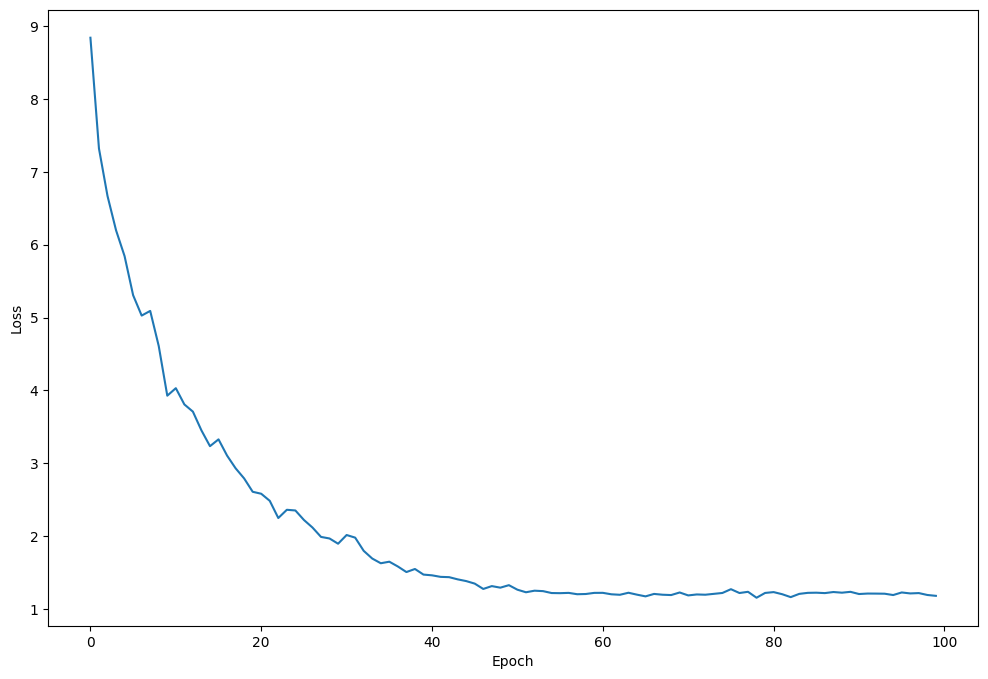

In [7]:
# Plot history of training losses over epochs.
plt.figure(figsize=(12,8))
plt.plot(epoch_losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

### 2.2Fine-tuning and Evaluation

### 2.2.1 Linear Model

#### Train

In [8]:
# This block performs linear evaluation on top of the pretrained SimCLR base model.
total_epochs = 50
batch_size = 128
tag = "linear_eval"
output_shape = np_train_unbalanced_labels.shape[1]  # Number of classes for classification

# 1. Loads the SimCLR model and attaches a linear classification head on top.
simclr_model = tf.keras.models.load_model(simclr_model_save_path)
linear_evaluation_model = simclr_models.create_linear_model_from_base_model(simclr_model, output_shape, intermediate_layer=7)

# 2. Sets up a ModelCheckpoint callback to save the best model (lowest validation loss).
# This ensures we keep the model version that performs best on validation data
linear_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(
    linear_eval_best_model_file_name,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,
    verbose=0
)

# 3. Trains the linear evaluation model using the training and validation data.
training_history = linear_evaluation_model.fit(
    x = np_train_unbalanced_data,
    y = np_train_unbalanced_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_unbalanced_data, np_val_unbalanced_labels)
)

Epoch 1/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - auc: 0.9753 - categorical_accuracy: 0.9605 - loss: 0.1783 - precision: 0.9605 - recall: 0.9605 - val_auc: 0.8683 - val_categorical_accuracy: 0.8551 - val_loss: 0.5710 - val_precision: 0.8551 - val_recall: 0.8551
Epoch 2/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9827 - categorical_accuracy: 0.9630 - loss: 0.1385 - precision: 0.9630 - recall: 0.9630 - val_auc: 0.9185 - val_categorical_accuracy: 0.8939 - val_loss: 0.3988 - val_precision: 0.8939 - val_recall: 0.8939
Epoch 3/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9858 - categorical_accuracy: 0.9650 - loss: 0.1279 - precision: 0.9650 - recall: 0.9650 - val_auc: 0.9475 - val_categorical_accuracy: 0.9161 - val_loss: 0.2893 - val_precision: 0.9161 - val_recall: 0.9161
Epoch 4/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9877 - categorical_accuracy: 0.9665 - loss: 0.1201 - precision: 0.9665 - recall: 0.9665 - val_auc: 0.9539 - val_categorical_accuracy: 0.920

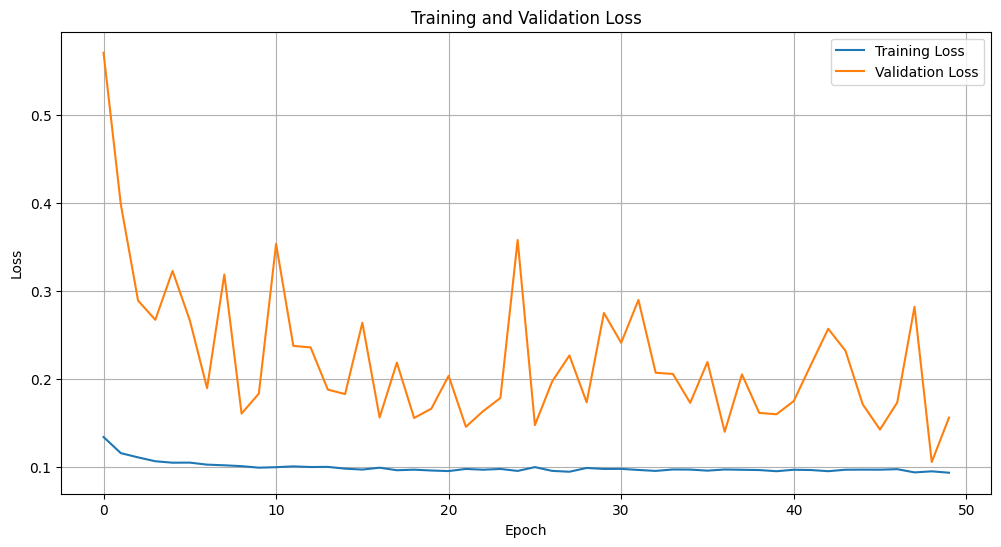

In [9]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

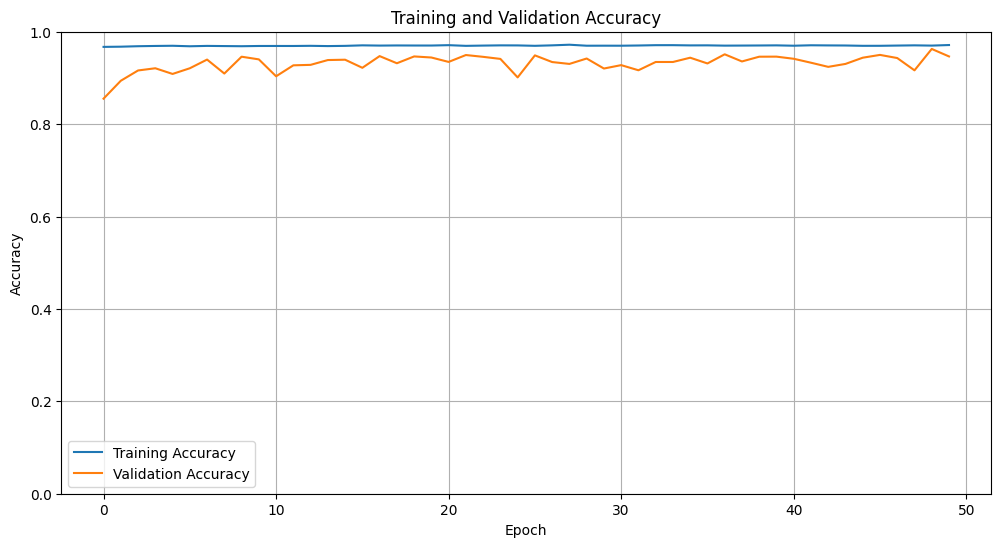

In [10]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [11]:
# Load models and evaluate on test set on vscode
linear_eval_model_path =  linear_eval_best_model_file_name

# Load both models
# simclr_model = tf.keras.models.load_model(simclr_model_path)
linear_eval_best_model = tf.keras.models.load_model(linear_eval_model_path)

In [12]:
linear_eval_best_model = tf.keras.models.load_model(linear_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(linear_eval_best_model.predict(np_test_unbalanced_data), np_test_unbalanced_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(linear_evaluation_model.predict(np_test_unbalanced_data), np_test_unbalanced_labels, return_dict=True))


Model with lowest validation Loss:
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
{'Confusion Matrix': array([[3357,  249],
       [  63,   39]]), 'F1 Macro': 0.577796754910333, 'F1 Micro': 0.9158576051779935, 'F1 Weighted': 0.9348085750844988, 'Precision': 0.5584978070175439, 'Recall': 0.6566506802388177, 'Kappa': np.float64(0.16612174996107754)}
Model in last epoch
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
{'Confusion Matrix': array([[3265,  341],
       [  49,   53]]), 'F1 Macro': 0.5786756479582323, 'F1 Micro': 0.8948220064724919, 'F1 Weighted': 0.9235625845192427, 'Precision': 0.5598660045522916, 'Recall': 0.7125216143029591, 'Kappa': np.float64(0.17777656482403836)}


### 2.2.2 Full HAR Model

#### Train

In [14]:
total_epochs = 50
batch_size = 128
tag = "full_eval"
output_shape = np_train_unbalanced_labels.shape[1]  # Number of classes for classification

simclr_model = tf.keras.models.load_model(simclr_model_save_path)
full_evaluation_model = simclr_models.create_full_classification_model_from_base_model(
    simclr_model, output_shape, model_name="TPN", intermediate_layer=7, last_freeze_layer=4)

full_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"

best_model_callback = tf.keras.callbacks.ModelCheckpoint(full_eval_best_model_file_name,
    monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=0
)

training_history = full_evaluation_model.fit(
    x = np_train_unbalanced_data,
    y = np_train_unbalanced_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_unbalanced_data, np_val_unbalanced_labels)
)



Epoch 1/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - auc: 0.9852 - categorical_accuracy: 0.9658 - loss: 0.1502 - precision: 0.9658 - recall: 0.9658 - val_auc: 0.9960 - val_categorical_accuracy: 0.9751 - val_loss: 0.0853 - val_precision: 0.9751 - val_recall: 0.9751
Epoch 2/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9942 - categorical_accuracy: 0.9703 - loss: 0.0929 - precision: 0.9703 - recall: 0.9703 - val_auc: 0.9963 - val_categorical_accuracy: 0.9776 - val_loss: 0.0798 - val_precision: 0.9776 - val_recall: 0.9776
Epoch 3/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9945 - categorical_accuracy: 0.9725 - loss: 0.0874 - precision: 0.9725 - recall: 0.9725 - val_auc: 0.9965 - val_categorical_accuracy: 0.9802 - val_loss: 0.0732 - val_precision: 0.9802 - val_recall: 0.9802
Epoch 4/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9952 - categorical_accuracy: 0.9755 - loss: 0.0804 - precision: 0.9755 - recall: 0.9755 - val_auc: 0.9969 - val_categorical_accuracy: 0.981

#### Plot metrics

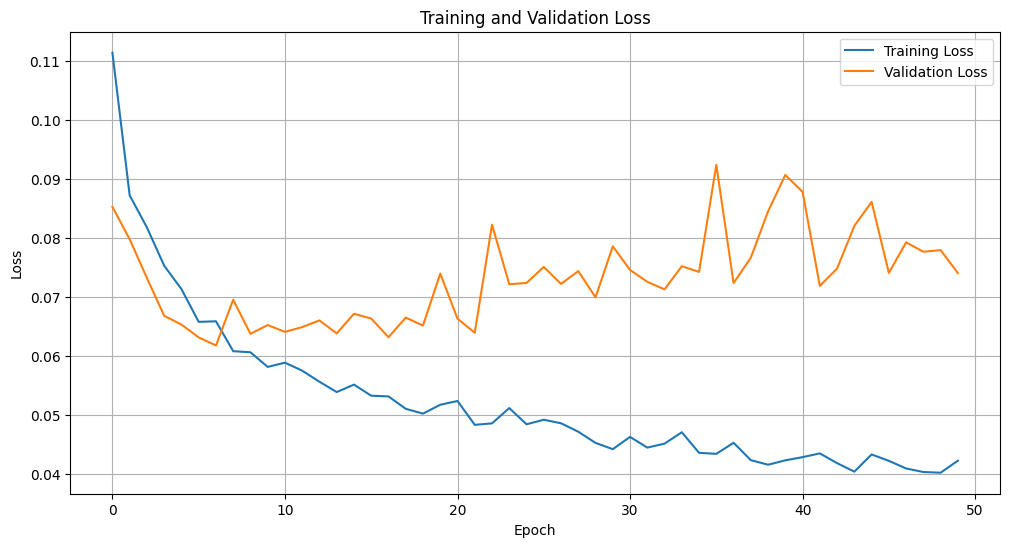

In [18]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

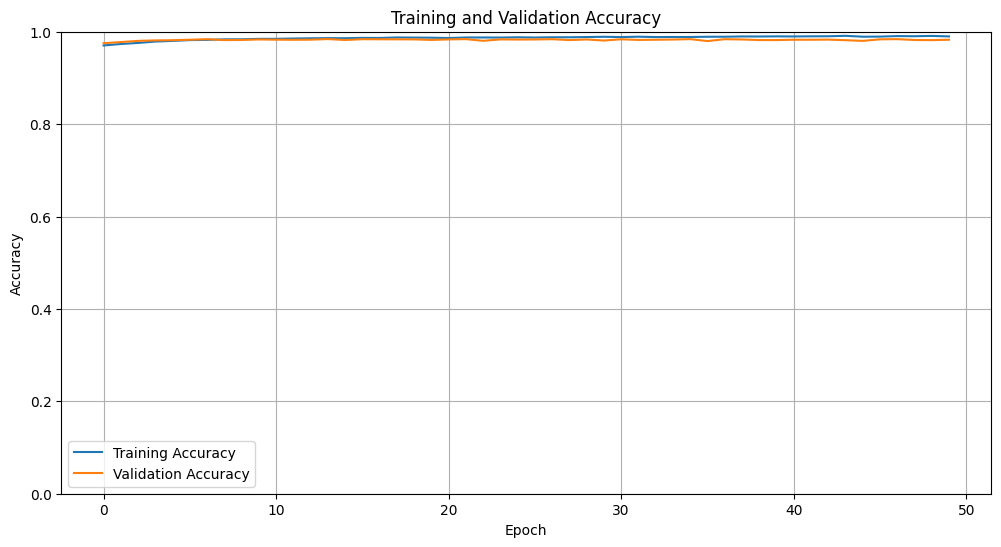

In [19]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

## 3.Evaluation of real world test data

In [20]:
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(full_eval_best_model.predict(np_test_unbalanced_data), np_test_unbalanced_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(full_evaluation_model.predict(np_test_unbalanced_data), np_test_unbalanced_labels, return_dict=True))

Model with lowest validation Loss:
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
{'Confusion Matrix': array([[3557,   49],
       [  83,   19]]), 'F1 Macro': 0.6026562322417236, 'F1 Micro': 0.9644012944983819, 'F1 Weighted': 0.96092494285431, 'Precision': 0.6283047834518423, 'Recall': 0.5863430230661316, 'Kappa': np.float64(0.2060575388328726)}
Model in last epoch
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
{'Confusion Matrix': array([[3501,  105],
       [  73,   29]]), 'F1 Macro': 0.6104858127567159, 'F1 Micro': 0.9519956850053938, 'F1 Weighted': 0.9551432414316489, 'Precision': 0.5979963083296445, 'Recall': 0.627597794525464, 'Kappa': np.float64(0.22144211986524354)}


#### Compare with threshold

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def evaluate_with_threshold(model, X_test, y_test, threshold=0.5):
    """
    Evaluate model with custom threshold.
    """
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba[:, 1] >= threshold).astype(int)

    # Convert to one-hot for evaluate_model_simple
    y_pred_onehot = np.zeros_like(y_pred_proba)
    y_pred_onehot[np.arange(len(y_pred)), y_pred] = 1

    results = simclr_utitlities.evaluate_model_simple(y_pred_onehot, y_test, return_dict=True)

    return results, y_pred_proba

In [25]:
# Get predictions for both models
y_pred_proba = full_eval_best_model.predict(np_test_unbalanced_data)
y_pred_proba_linear = linear_eval_best_model.predict(np_test_unbalanced_data)

# Set threshold
threshold = 0.1

# Evaluate Full Model with threshold 0.1
print(f"\n=== Full Model - Threshold {threshold} ===")
results_full, _ = evaluate_with_threshold(full_eval_best_model, np_test_unbalanced_data, np_test_unbalanced_labels, threshold=threshold)
print(results_full)

# Evaluate Linear Model with threshold 0.1
print(f"\n=== Linear Model - Threshold {threshold} ===")
results_linear, _ = evaluate_with_threshold(linear_eval_best_model, np_test_unbalanced_data, np_test_unbalanced_labels, threshold=threshold)
print(results_linear)

# Compare both models
print("\n=== Comparison: Linear vs Full Model (Threshold 0.1) ===")
print(f"Linear Model - Threshold: {threshold}")
print(results_linear)
print(f"\nFull Model - Threshold: {threshold}")
print(results_full)

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=== Full Model - Threshold 0.1 ===
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
{'Confusion Matrix': array([[3236,  370],
       [  47,   55]]), 'F1 Macro': 0.5740986854989516, 'F1 Micro': 0.8875404530744336, 'F1 Weighted': 0.9193674543089138, 'Precision': 0.557547795237498, 'Recall': 0.7183044598871162, 'Kappa': np.float64(0.17199167191456)}

=== Linear Model - Threshold 0.1 ===
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
{'Confusion Matrix': array([[2948,  658],
       [  24,   78]]), 'F1 Macro': 0.5412392940669375, 'F1 Micro': 0.8160733549083063, 'F1 Weighted': 0.8767858268851104, 'Precision': 0.5489514453742174, 'Recall': 0.7911161136667646, 'Kappa': np.float64(0.14483626181877196)}

=== Comparison: Linear vs Full Model (Threshold 0.1) ===
Linear Model - Threshold: 0.1
{'Confusion Matrix': array([[2948,  658],
       [  24,   78]]), 'F1 Macro': 0.5412392940669375, 'F1 Micro': 0.8160733549083063, 'F1 Weighte

## 4.Generate pseodo labels for field validation data

In [ ]:
# load models and test data
# Load models
base_model_path = "../../models/1s_30hz/2class_unbalanced_real_world_a/20251208-101322_simclr.hdf5"
linear_model_path = "../../models/1s_30hz/2class_unbalanced_real_world_a/20251208-101322_simclr_linear_eval.keras"
full_model_path = "../../models/1s_30hz/2class_unbalanced_real_world_a/20251208-101322_simclr_full_eval.keras"

simclr_model = tf.keras.models.load_model(base_model_path)
linear_eval_best_model = tf.keras.models.load_model(linear_model_path)
full_eval_best_model = tf.keras.models.load_model(full_model_path)

# Load
with open('../../data/Training/1s_30hz/lab_real_world_2class_unbalanced_version_a/X_test_normalized.pkl', 'rb') as f:
    subject_a_data = pickle.load(f)
with open('../../data/Training/1s_30hz/lab_real_world_2class_unbalanced_version_a/y_test_onehot.pkl', 'rb') as f:
    subject_a_labels = pickle.load(f)

subject_a_data.shape, subject_a_labels.shape

((3708, 30, 3), (3708, 2))

In [ ]:
# Load the linear model
linear_eval_best_model = tf.keras.models.load_model(linear_model_path)

# Get predictions on field validation data
y_pred_proba_subject_a = linear_eval_best_model.predict(subject_a_data)

# Apply threshold
threshold = 0.596
y_pred_subject_a = (y_pred_proba_subject_a[:, 1] >= threshold).astype(int)
# Compare predictions with true labels
y_true_subject_a = subject_a_labels.argmax(axis=1)

# Also evaluate using the existing function
y_pred_onehot_subject_a = np.zeros_like(y_pred_proba_subject_a)
y_pred_onehot_subject_a[np.arange(len(y_pred_subject_a)), y_pred_subject_a] = 1

print(f"\n=== Using evaluate_model_simple ===")
results = simclr_utitlities.evaluate_model_simple(y_pred_onehot_subject_a, subject_a_labels, return_dict=True)
print(results)

 10/116 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step   

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

=== Using evaluate_model_simple ===
{'Confusion Matrix': array([[3219,  387],
       [  40,   62]]), 'F1 Macro': 0.5814229045250442, 'F1 Micro': 0.8848435814455232, 'F1 Weighted': 0.91819390608645, 'Precision': 0.5629054644633227, 'Recall': 0.7502610029036573, 'Kappa': np.float64(0.18867216804201048)}


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


In [ ]:
# Save predictions
predictions_dict = {
    'Predicted Label': y_pred_subject_a,
}

output_path = '../../data/Training/1s_30hz/lab_real_world_2class_unbalanced_version_a/y_test_predictions_threshold_0.596_integer.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(predictions_dict, f)

## Extra: t-SNE Plots

In [ ]:
import sklearn.manifold
import seaborn as sns

### t-SNE Representations

In [ ]:
# First load the model from the file path
target_model_path = simclr_model_save_path
loaded_model = tf.keras.models.load_model(target_model_path)
perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(loaded_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(np_test_unbalanced_data, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "base_model_simclr_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 84,416 (329.75 KB)

 Non-trainable params: 0 (0.00 B)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3708 samples in 0.001s...
[t-SNE] Computed neighbors for 3708 samples in 0.276s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3708
[t-SNE] Computed conditional probabilities for sample 2000 / 3708
[t-SNE] Computed conditional probabilities for sample 3000 / 3708
[t-SNE] Computed conditional probabilities for sample 3708 / 3708
[t-SNE] Mean sigma: 0.610660
[t-SNE] KL divergence after 250 iterations with early exaggeration: 70.477928
[t-SNE] KL divergence after 1000 iterations: 1.075021


### Plotting

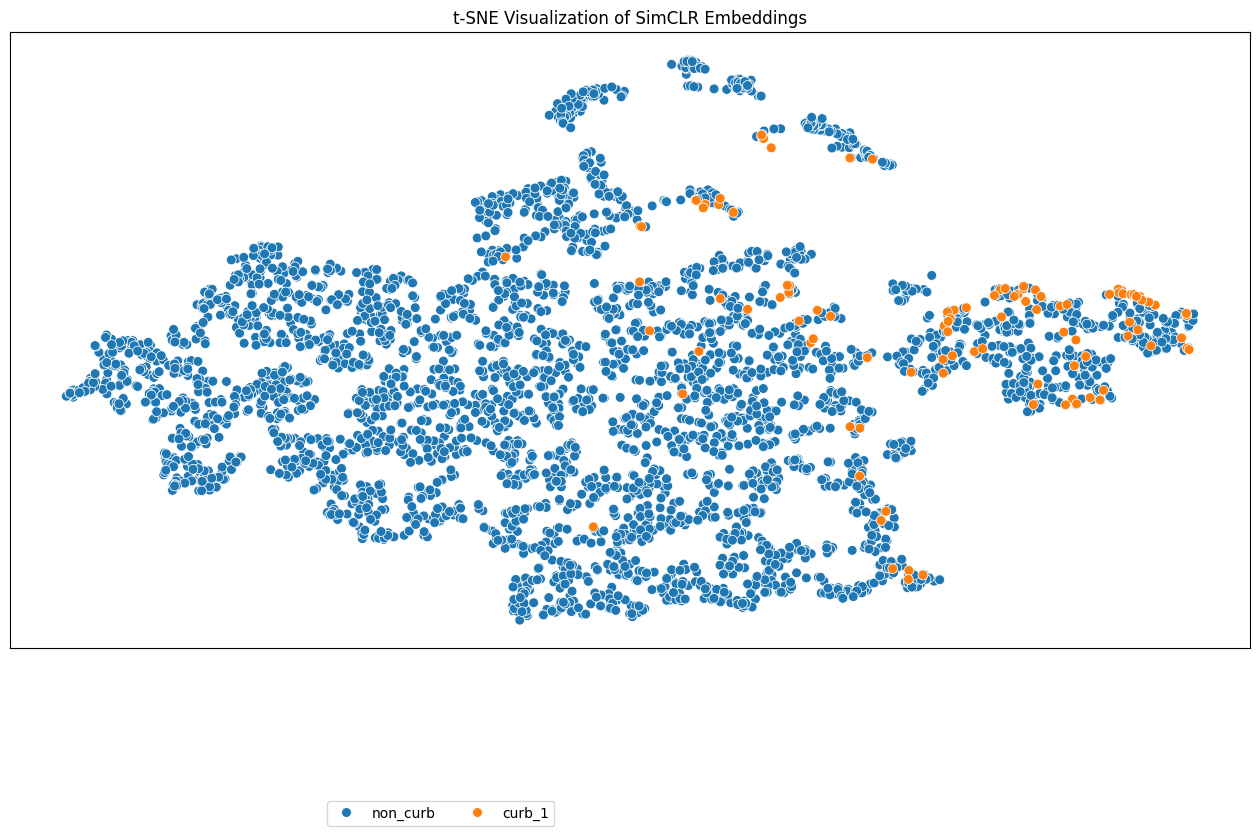

In [ ]:
# Define colors
other_class_color = "#1f77b4"  # Blue
curb_1_color = "#ff7f0e"      # Yellow

# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(np_test_unbalanced_labels, axis=1)
unique_labels = np.unique(labels_argmax)

# Create custom color palette
custom_palette = [other_class_color, curb_1_color]  # First color for non_curb (0), second for curb_1 (1)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=custom_palette,  # Use custom palette instead of "hsv"
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# Define your activity names
label_list_full_name = ["non_curb", "curb_1"]

# Update legend with custom colors
try:
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
    legend = graph.legend_
    if 'label_list_full_name' in globals():
        for j, label in enumerate(unique_labels):
            if label < len(label_list_full_name):
                legend.get_texts()[j].set_text(label_list_full_name[label])
except Exception as e:
    print(f"Warning: Could not customize legend - {e}")
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)

## 5.Anayse

In [ ]:
# load model local
base_model_path   = "../../models/1s_30hz/2class_unbalanced_real_world_a/20251208-101322_simclr.hdf5"
linear_model_path = "../../models/1s_30hz/2class_unbalanced_real_world_a/20251208-101322_simclr_linear_eval.keras"
full_model_path   = "../../models/1s_30hz/2class_unbalanced_real_world_a/20251208-101322_simclr_full_eval.keras"

simclr_model = tf.keras.models.load_model(base_model_path)
linear_eval_best_model = tf.keras.models.load_model(linear_model_path)
full_eval_best_model = tf.keras.models.load_model(full_model_path)

print("Loaded:", base_model_path, linear_model_path, full_model_path, sep="\n")


Loaded:
../../models/1s_30hz/2class_unbalanced_real_world_a/20251208-101322_simclr.hdf5
../../models/1s_30hz/2class_unbalanced_real_world_a/20251208-101322_simclr_linear_eval.keras
../../models/1s_30hz/2class_unbalanced_real_world_a/20251208-101322_simclr_full_eval.keras


In [ ]:
# load test data
with open('../../data/Training/1s_30hz/lab_real_world_2class_unbalanced_version_a/X_test_normalized.pkl', 'rb') as f:
    np_test_unbalanced_data = pickle.load(f)
with open('../../data/Training/1s_30hz/lab_real_world_2class_unbalanced_version_a/y_test_onehot.pkl', 'rb') as f:
    np_test_unbalanced_labels = pickle.load(f)

In [ ]:

# Evaluate linear_eval_best_model on test data
linear_eval_best_model = tf.keras.models.load_model(linear_model_path)
print(simclr_utitlities.evaluate_model_simple(
    linear_eval_best_model.predict(np_test_unbalanced_data),
    np_test_unbalanced_labels,
    return_dict=True
))

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


{'Confusion Matrix': array([[3166,  440],
       [  36,   66]]), 'F1 Macro': 0.5735937596635537, 'F1 Micro': 0.8716289104638619, 'F1 Weighted': 0.9104696204391279, 'Precision': 0.5595959047334547, 'Recall': 0.7625199830348113, 'Kappa': np.float64(0.17953924248340491)}


In [ ]:
# ...existing code...
# Evaluate linear_eval_best_model at custom threshold
linear_eval_best_model = tf.keras.models.load_model(linear_model_path)
y_pred_proba = linear_eval_best_model.predict(np_test_unbalanced_data)

thr = 0.596
y_pred = (y_pred_proba[:, 1] >= thr).astype(int)

# one-hot for evaluate_model_simple
y_pred_onehot = np.zeros_like(y_pred_proba)
y_pred_onehot[np.arange(len(y_pred)), y_pred] = 1

print(f"Linear model @thr={thr}:",
      simclr_utitlities.evaluate_model_simple(y_pred_onehot, np_test_unbalanced_labels, return_dict=True))

 12/116 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step   

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Linear model @thr=0.596: {'Confusion Matrix': array([[3219,  387],
       [  40,   62]]), 'F1 Macro': 0.5814229045250442, 'F1 Micro': 0.8848435814455232, 'F1 Weighted': 0.91819390608645, 'Precision': 0.5629054644633227, 'Recall': 0.7502610029036573, 'Kappa': np.float64(0.18867216804201048)}


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


In [ ]:
# save the index of tp, tn, fp, fn for linear model
y_true = np_test_unbalanced_labels.argmax(axis=1)
tp_indices = np.where((y_pred == 1) & (y_true == 1))[0]
tn_indices = np.where((y_pred == 0) & (y_true == 0))[0]
fp_indices = np.where((y_pred == 1) & (y_true == 0))[0]
fn_indices = np.where((y_pred == 0) & (y_true == 1))[0]